# SaaS / Subscription Churn Prediction & Analysis

## Exploratory Data Analysis

### Objective

Explore the raw customer subscription dataset to understand:

- Dataset structure and data quality
- Customer and subscription characteristics
- Churn distribution
- Numerical feature distributions
- Categorical feature distributions
- Potential relationships between customer attributes and churn

### Business Objective

Identify customers at risk of churn and quantify the recurring revenue potentially at risk so that the business can prioritize retention efforts.

### Analysis Principle

This analysis will prioritize business relevance, interpretability, and clear reasoning over unnecessary feature complexity.

## EDA Roadmap

1. Load the raw dataset
2. Inspect dataset structure
3. Audit data quality
4. Investigate potential hidden/malformed missing values
5. Analyze churn class balance
6. Analyze numerical variables
7. Analyze categorical variables
8. Compare customer characteristics by churn status
9. Identify initial business patterns
10. Document observations and implications

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load Raw Dataset

The raw dataset is loaded directly from `data/raw/` and is not modified during the initial inspection stage.

In [179]:
file_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Structure

The first structural checks establish the dataset size, column names, data types, and overall composition before any cleaning or transformation is performed.

In [180]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 7,043
Columns: 21


In [181]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [183]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,"7,043.00",NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,"7,043.00",NaN,NaN,NaN,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Raw Data Quality Audit

Before performing transformations or feature engineering, the raw dataset is
audited for duplicates, null values, blank values, identifier uniqueness,
data types, and categorical-value consistency.

The purpose of this stage is to understand the quality of the source data
before making any cleaning decisions.

### 3.1 Duplicate Records

Duplicate records can distort customer-level churn rates and revenue
calculations, so duplicate rows are checked before analysis.

In [184]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


### 3.2 Missing Values

A standard null-value audit is performed using Pandas `isna()`.

This is only the first stage of the missing-value investigation because
blank strings or whitespace-only values may not be recognized as nulls.

In [185]:
null_counts = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

null_counts

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [186]:
print(f"Total null cells: {df.isna().sum().sum():,}")

Total null cells: 0


### 3.3 Blank and Whitespace-Only Values

The raw CSV may contain blank or whitespace-only strings that are not
identified by `isna()`.

Each object/string column is therefore checked for values that are empty
after removing surrounding whitespace.

In [187]:
object_columns = df.select_dtypes(include="object").columns

blank_counts = {}

for col in object_columns:
    blank_counts[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

blank_counts = (
    pd.Series(blank_counts)
    .sort_values(ascending=False)
)

blank_counts

TotalCharges        11
customerID           0
gender               0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
DeviceProtection     0
OnlineBackup         0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
Dependents           0
Partner              0
Churn                0
dtype: int64

In [188]:
blank_counts[blank_counts > 0]

TotalCharges    11
dtype: int64

### 3.4 TotalCharges Data-Type Investigation

`TotalCharges` represents cumulative charges but was loaded as an object
column rather than a numeric column.

The column is investigated for non-numeric or blank values before deciding
how it should be cleaned and converted.

In [189]:
total_charges_as_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

conversion_failures = (
    df["TotalCharges"].notna()
    & total_charges_as_numeric.isna()
)

print(f"Values that fail numeric conversion: {conversion_failures.sum():,}")

Values that fail numeric conversion: 11


In [190]:
df.loc[conversion_failures, ["customerID", "tenure", "TotalCharges", "Churn"]]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [191]:
df.loc[
    conversion_failures,
    ["tenure", "Churn"]
].sort_values("tenure")

,tenure,Churn
488,0,No
753,0,No
936,0,No
1082,0,No
1340,0,No
3331,0,No
3826,0,No
4380,0,No
5218,0,No
6670,0,No


### 3.5 Customer Identifier Uniqueness

Because the analysis is performed at customer level, each `customerID`
should represent one customer record.

Customer identifier uniqueness is therefore checked before downstream
aggregation and modeling.

In [192]:
unique_customers = df["customerID"].nunique()
total_rows = len(df)

print(f"Total rows: {total_rows:,}")
print(f"Unique customer IDs: {unique_customers:,}")
print(f"Duplicate customer IDs: {total_rows - unique_customers:,}")

Total rows: 7,043
Unique customer IDs: 7,043
Duplicate customer IDs: 0


### 3.6 Categorical Value Consistency

Categorical columns are reviewed for unexpected spellings, inconsistent
capitalization, or unusual categories that could affect segmentation.

In [193]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- customerID ---
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup -

### 3.7 Raw Data Quality Summary

The initial audit produced the following observations:

- The dataset contains 7,043 customer records and 21 columns.
- No duplicate rows were identified.
- No Pandas null values were detected through `isna()`.
- A separate blank-value audit identified 11 blank values in `TotalCharges`.
- All 11 `TotalCharges` records that failed numeric conversion correspond to customers with `tenure = 0`.
- All 11 of these customers are currently classified as non-churned (`Churn = No`).
- `customerID` is unique across all 7,043 records.
- The categorical variables showed consistent category labels with no obvious spelling or capitalization inconsistencies.
- `TotalCharges` requires explicit cleaning and numeric conversion before it can be reliably used in downstream analysis.

No values are modified or removed during this raw-data audit. Cleaning decisions are deferred to the dedicated Pandas cleaning and feature-engineering stage.

## 4. Churn Baseline

The churn baseline establishes the size of the customer-retention problem before investigating the characteristics associated with churn.

This baseline will be used as a reference point for subsequent segmentation, predictive modeling, and revenue-at-risk analysis.

### 4.1 Customer Churn Counts

In [194]:
customer_counts = df["Churn"].value_counts()

total_customers = len(df)
churned_customers = customer_counts.get("Yes", 0)
retained_customers = customer_counts.get("No", 0)

print(f"Total customers: {total_customers:,}")
print(f"Churned customers: {churned_customers:,}")
print(f"Retained customers: {retained_customers:,}")

Total customers: 7,043
Churned customers: 1,869
Retained customers: 5,174


### 4.2 Churn and Retention Rates

In [195]:
churn_rate = churned_customers / total_customers
retention_rate = retained_customers / total_customers

print(f"Churn rate: {churn_rate:.2%}")
print(f"Retention rate: {retention_rate:.2%}")

Churn rate: 26.54%
Retention rate: 73.46%


In [196]:
churn_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate",
        "Retention Rate"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        churn_rate,
        retention_rate
    ]
})

churn_summary

,Metric,Value
0,Total Customers,"7,043.00"
1,Churned Customers,"1,869.00"
2,Retained Customers,"5,174.00"
3,Churn Rate,0.27
4,Retention Rate,0.73


### 4.3 Churn Distribution

The churn distribution provides a visual view of the proportion of customers who have churned versus those who remain active.

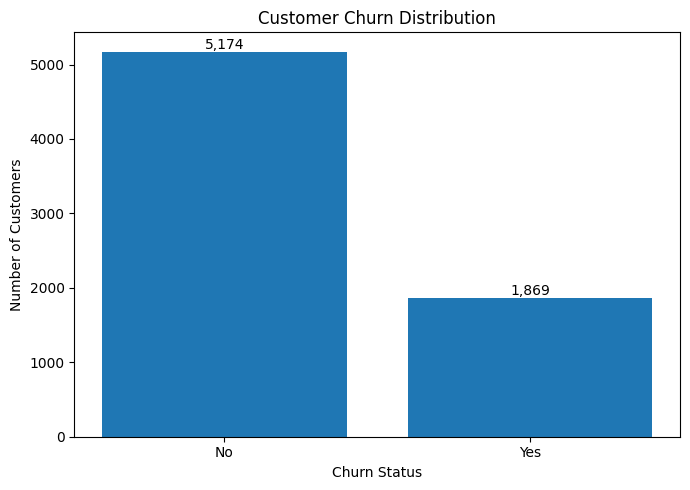

In [197]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [198]:
churn_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

churn_percentages

Churn
No    73.46
Yes   26.54
Name: proportion, dtype: float64

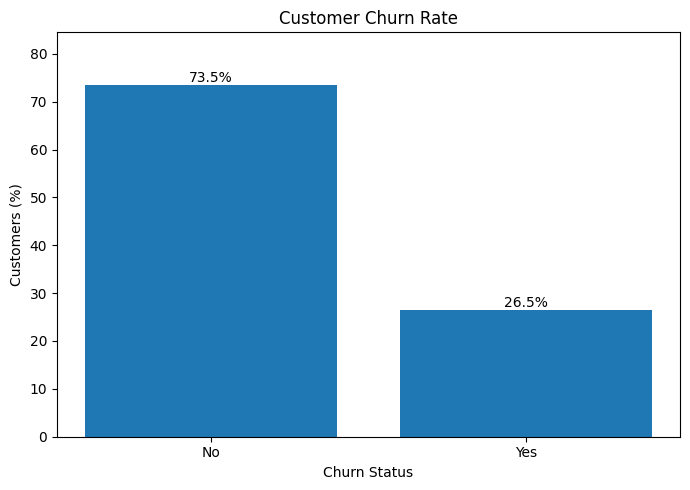

In [199]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_percentages.index,
    churn_percentages.values
)

plt.title("Customer Churn Rate")
plt.xlabel("Churn Status")
plt.ylabel("Customers (%)")

for bar, value in zip(bars, churn_percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(churn_percentages.values) * 1.15)
plt.tight_layout()
plt.show()

### 4.4 Initial Business Interpretation

The dataset contains 7,043 customers, of whom 1,869 have churned and 5,174 have remained active.

The overall churn rate is 26.54%, meaning that more than one quarter of the observed customer base has churned.

This establishes a meaningful retention problem and provides the baseline against which customer segments and future churn-risk predictions can be evaluated.

The baseline alone does not explain why customers churn or which customers should be targeted for retention. Further analysis is required to identify the customer and subscription characteristics associated with higher churn.

## 5. Numerical Feature Distributions

Numerical variables are examined to understand their distributions and identify potential differences in customer characteristics.

The primary numerical variables are:

- `tenure`: customer relationship duration in months
- `MonthlyCharges`: recurring monthly customer charges
- `TotalCharges`: cumulative customer charges

`TotalCharges` requires additional cleaning because the raw dataset contains blank values and is currently loaded as an object column. Therefore, it will not be used as a cleaned numerical variable until the dedicated data-cleaning stage.

### 5.1 Summary Statistics

In [200]:
numeric_columns = ["tenure", "MonthlyCharges"]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.00",32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,"7,043.00",64.76,30.09,18.25,35.50,70.35,89.85,118.75


### 5.2 Customer Tenure Distribution

Customer tenure represents the number of months a customer has remained with the company.

Understanding tenure is important because customer relationship duration may help explain differences in churn behavior.

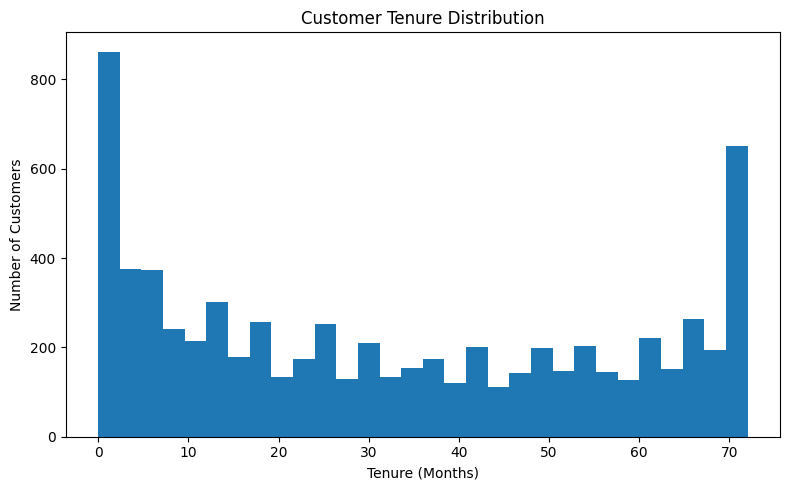

In [201]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["tenure"],
    bins=30
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 5.3 Monthly Charges Distribution

Monthly charges represent the recurring amount associated with each customer.

The distribution helps establish the range and concentration of recurring customer charges before analyzing revenue at risk.

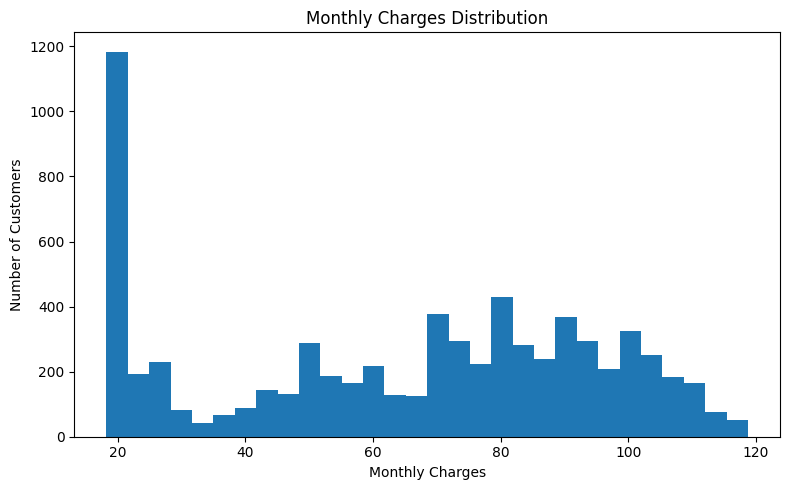

In [202]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["MonthlyCharges"],
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### 5.4 Numerical Features by Churn Status

Numerical characteristics are compared across churn groups to identify descriptive differences that may warrant further investigation.

These comparisons are descriptive and should not be interpreted as causal relationships.

In [203]:
# Tenure by churn
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,"5,174.00",37.57,24.11,0.00,15.00,38.00,61.00,72.00
Yes,"1,869.00",17.98,19.53,1.00,2.00,10.00,29.00,72.00


In [204]:
# Monthly charges by churn
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,"5,174.00",61.27,31.09,18.25,25.10,64.43,88.40,118.75
Yes,"1,869.00",74.44,24.67,18.85,56.15,79.65,94.20,118.35


<Figure size 800x500 with 0 Axes>

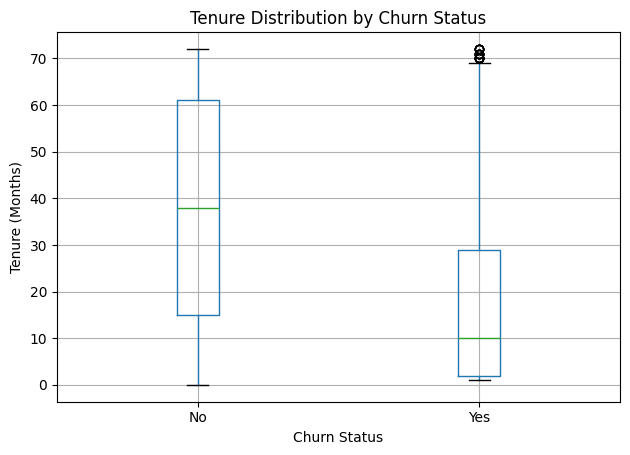

In [205]:
# Tenure-by-Churn Visualization
plt.figure(figsize=(8, 5))

df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

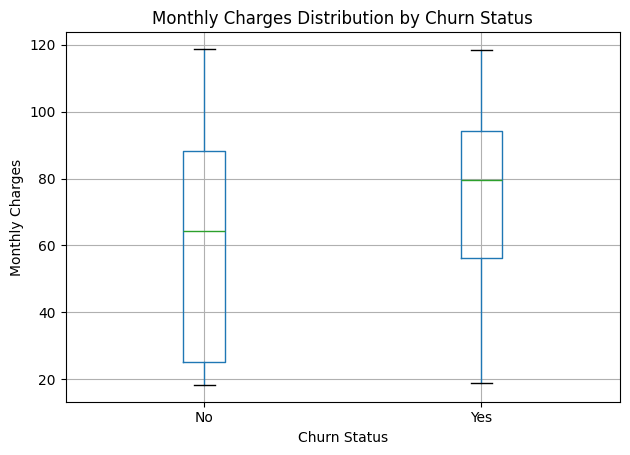

In [206]:
# Monthly Charges by Churn Visualization
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [207]:
# Calculate the group means
numerical_churn_summary = (
    df.groupby("Churn")[["tenure", "MonthlyCharges"]]
      .mean()
      .round(2)
)

numerical_churn_summary

,tenure,MonthlyCharges
Churn,,
No,37.57,61.27
Yes,17.98,74.44


In [208]:
# Calculate the group medians
numerical_churn_median = (
    df.groupby("Churn")[["tenure", "MonthlyCharges"]]
      .median()
      .round(2)
)

numerical_churn_median

,tenure,MonthlyCharges
Churn,,
No,38.00,64.43
Yes,10.00,79.65


### 5.5 Numerical Feature Findings

The numerical analysis shows meaningful descriptive differences between
customers who churned and those who remained.

#### Tenure

Churned customers have substantially shorter customer relationships than
retained customers.

- Retained customers have an average tenure of 37.57 months and a median
  tenure of 38 months.
- Churned customers have an average tenure of 17.98 months and a median
  tenure of 10 months.

The large difference in median tenure suggests that early-stage customers
represent an important population for further churn-risk investigation.

#### Monthly Charges

Churned customers also show higher monthly charges on average.

- Retained customers have average monthly charges of $61.27 and median
  monthly charges of $64.43.
- Churned customers have average monthly charges of $74.44 and median
  monthly charges of $79.65.

This difference is particularly relevant to the business objective because
customers with higher recurring charges may represent greater potential
revenue exposure when they churn.

These findings are descriptive associations rather than causal conclusions.
Further analysis of subscription characteristics and customer segments is
required to determine which factors are most strongly associated with churn.

## 6. Categorical Churn Analysis

Categorical customer and subscription characteristics are analyzed by
calculating churn rates within each segment.

The analysis focuses on business-relevant variables that could potentially
support customer-retention prioritization.

Churn rate is calculated within each category rather than relying only on
absolute churn counts, because category sizes differ.

In [209]:
# Create a Reusable Churn-Rate Function
def calculate_churn_rate(data, column):
    summary = (
        data.groupby(column)["ChurnFlag"]
        .agg(
            customers="count",
            churned="sum"
        )
        .reset_index()
    )

    summary["churn_rate"] = (
        summary["churned"] / summary["customers"]
    )

    return summary.sort_values(
        "churn_rate",
        ascending=False
    )

### 6.1 Churn Rate Calculation

For segment-level churn calculations, the categorical target is temporarily
mapped to a binary indicator:

- `1` = churned
- `0` = retained

This analytical flag does not modify the raw dataset.

In [210]:
df["ChurnFlag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [211]:
# Validation
df["ChurnFlag"].value_counts(dropna=False)

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64

### 6.2 Contract Type

Contract type is analyzed because subscription commitment may be relevant to
customer retention.

The objective is to compare the observed churn rate across contract types,
not to infer causation.

In [212]:
contract_churn = calculate_churn_rate(
    df,
    "Contract"
)

contract_churn

,Contract,customers,churned,churn_rate
0,Month-to-month,3875,1655,0.43
1,One year,1473,166,0.11
2,Two year,1695,48,0.03


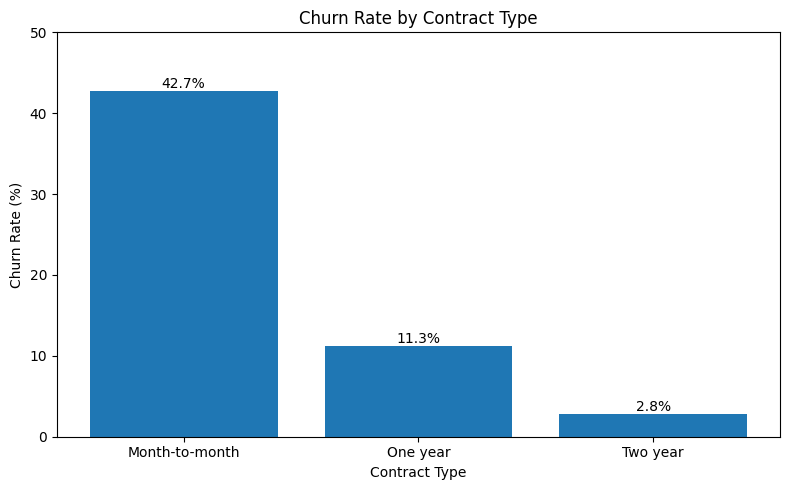

In [213]:
# Visualize Contract Churn
plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_churn["Contract"],
    contract_churn["churn_rate"] * 100
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    contract_churn["churn_rate"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

### 6.3 Internet Service

Internet service type is compared across churn groups to determine whether
different service categories exhibit different observed churn rates.

In [214]:
internet_churn = calculate_churn_rate(
    df,
    "InternetService"
)

internet_churn

,InternetService,customers,churned,churn_rate
1,Fiber optic,3096,1297,0.42
0,DSL,2421,459,0.19
2,No,1526,113,0.07


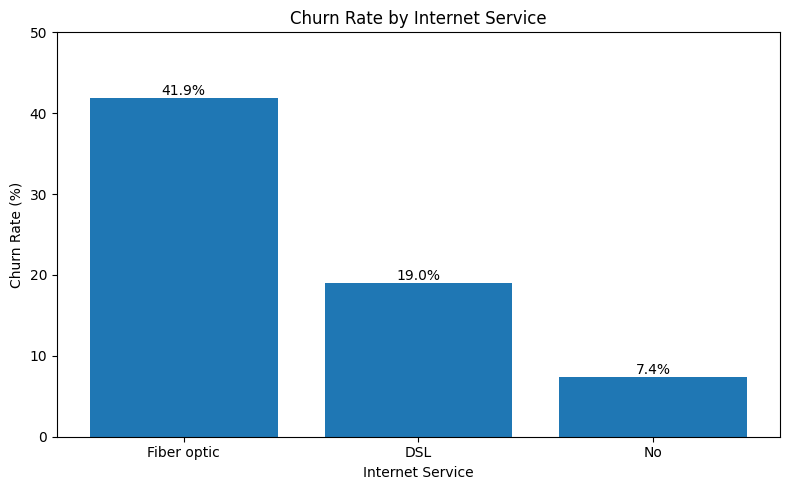

In [215]:
# Visualize Internet Service Churn
plt.figure(figsize=(8, 5))

bars = plt.bar(
    internet_churn["InternetService"],
    internet_churn["churn_rate"] * 100
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(
    bars,
    internet_churn["churn_rate"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

### 6.4 Payment Method

Payment method is analyzed to identify whether observed churn rates differ
across payment channels.

Any relationship identified here will be treated as descriptive and will
require validation through the predictive modeling stage.

In [216]:
payment_churn = calculate_churn_rate(
    df,
    "PaymentMethod"
)

payment_churn

,PaymentMethod,customers,churned,churn_rate
2,Electronic check,2365,1071,0.45
3,Mailed check,1612,308,0.19
0,Bank transfer (automatic),1544,258,0.17
1,Credit card (automatic),1522,232,0.15


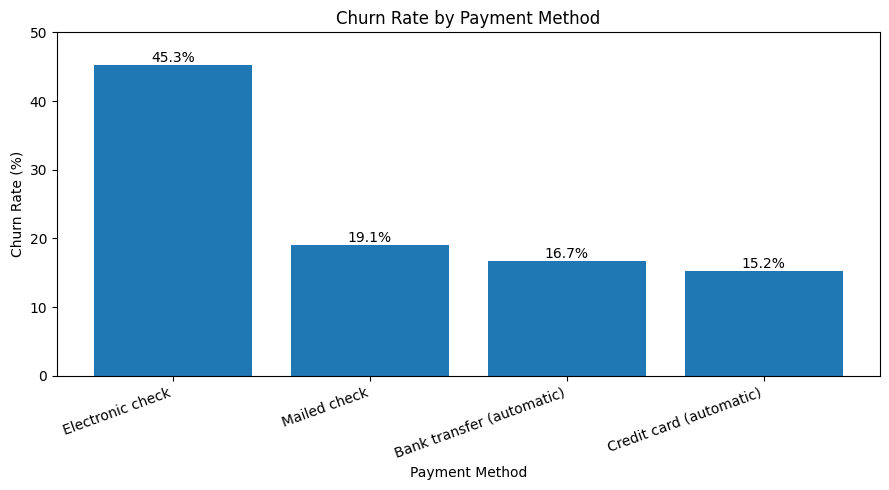

In [217]:
# Visualize Payment Method Churn
plt.figure(figsize=(9, 5))

bars = plt.bar(
    payment_churn["PaymentMethod"],
    payment_churn["churn_rate"] * 100
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(
    bars,
    payment_churn["churn_rate"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

In [218]:
# Analyze Support & Security Services
tech_support_churn = calculate_churn_rate(
    df,
    "TechSupport"
)

online_security_churn = calculate_churn_rate(
    df,
    "OnlineSecurity"
)

print("TechSupport")
display(tech_support_churn)

print("\nOnlineSecurity")
display(online_security_churn)

TechSupport


,TechSupport,customers,churned,churn_rate
0,No,3473,1446,0.42
2,Yes,2044,310,0.15
1,No internet service,1526,113,0.07



OnlineSecurity


,OnlineSecurity,customers,churned,churn_rate
0,No,3498,1461,0.42
2,Yes,2019,295,0.15
1,No internet service,1526,113,0.07


In [219]:
# Comparison table of Support by Churn & Security Services by Churn
service_summary = pd.DataFrame({
    "Service": ["TechSupport", "OnlineSecurity"],
    "No": [
        tech_support_churn.loc[
            tech_support_churn["TechSupport"] == "No",
            "churn_rate"
        ].iloc[0],
        online_security_churn.loc[
            online_security_churn["OnlineSecurity"] == "No",
            "churn_rate"
        ].iloc[0]
    ],
    "Yes": [
        tech_support_churn.loc[
            tech_support_churn["TechSupport"] == "Yes",
            "churn_rate"
        ].iloc[0],
        online_security_churn.loc[
            online_security_churn["OnlineSecurity"] == "Yes",
            "churn_rate"
        ].iloc[0]
    ]
})

service_summary["No"] = service_summary["No"] * 100
service_summary["Yes"] = service_summary["Yes"] * 100

service_summary.round(1)

,Service,No,Yes
0,TechSupport,41.60,15.20
1,OnlineSecurity,41.80,14.60


### 6.5 Senior Citizen Status

Senior citizen status is analyzed as a demographic segmentation variable to
determine whether observed churn rates differ between the two groups.

In [220]:
senior_churn = calculate_churn_rate(
    df,
    "SeniorCitizen"
)

senior_churn

,SeniorCitizen,customers,churned,churn_rate
1,1,1142,476,0.42
0,0,5901,1393,0.24


### 6.6 Key Categorical Churn Signals

In [221]:
categorical_signal_summary = pd.DataFrame({
    "Feature": [
        "Contract",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity",
        "SeniorCitizen"
    ],
    "Highest_Risk_Segment": [
        "Month-to-month",
        "Fiber optic",
        "Electronic check",
        "No",
        "No",
        "Senior citizen"
    ],
    "Highest_Churn_Rate": [
        contract_churn["churn_rate"].max(),
        internet_churn["churn_rate"].max(),
        payment_churn["churn_rate"].max(),
        tech_support_churn["churn_rate"].max(),
        online_security_churn["churn_rate"].max(),
        senior_churn["churn_rate"].max()
    ]
})

categorical_signal_summary["Highest_Churn_Rate"] = (
    categorical_signal_summary["Highest_Churn_Rate"] * 100
).round(1)

categorical_signal_summary

,Feature,Highest_Risk_Segment,Highest_Churn_Rate
0,Contract,Month-to-month,42.70
1,InternetService,Fiber optic,41.90
2,PaymentMethod,Electronic check,45.30
3,TechSupport,No,41.60
4,OnlineSecurity,No,41.80
5,SeniorCitizen,Senior citizen,41.70


### 6.7 Categorical Feature Findings

Several customer and subscription segments show materially different
observed churn rates.

- Month-to-month customers have a 43% churn rate, compared with 11% for
  one-year contracts and 3% for two-year contracts.
- Customers using electronic checks have the highest observed churn rate
  among payment methods at approximately 45%.
- Fiber-optic customers have an observed churn rate of approximately 42%,
  compared with 19% for DSL customers and 7% for customers without internet
  service.
- Customers without TechSupport or OnlineSecurity show churn rates of
  approximately 42%, compared with approximately 15% among customers who
  subscribe to these services.
- Senior citizens have an observed churn rate of approximately 42%, compared
  with 24% among non-senior customers.

The strongest descriptive differences appear around contract type, payment
method, internet service, and support/security service adoption.

These results identify segments for further investigation and potential
retention prioritization. They should not be interpreted as causal effects.
The predictive modeling stage will test whether these characteristics remain
associated with churn when considered together with other customer
attributes.

## 7. EDA-to-Business Synthesis

The initial EDA establishes the baseline characteristics of the churn problem and identifies several segments that warrant further investigation.

### Baseline

The dataset contains 7,043 customers with an observed churn rate of 26.54%.

### Customer Tenure

Churned customers have substantially shorter observed tenure than retained customers. Median tenure is 10 months among churned customers compared with 38 months among retained customers.

This suggests that early-stage customers may represent an important retention-risk population.

### Monthly Charges

Churned customers have higher average monthly charges than retained customers ($74.44 versus $61.27).

This is relevant to the project because churn among higher-value customers can create greater recurring revenue exposure.

### Subscription Characteristics

Month-to-month customers show a 43% observed churn rate, compared with 11% for one-year contracts and 3% for two-year contracts.

### Payment Method

Electronic-check customers show the highest observed churn rate among payment methods at approximately 45%.

### Internet Service

Fiber-optic customers show an observed churn rate of approximately 42%, compared with 19% for DSL customers.

### Support and Security Services

Customers without TechSupport or OnlineSecurity show observed churn rates of approximately 42%, compared with approximately 15% among customers with these services.

### Business Question for the Next Stage

The EDA identifies several characteristics associated with higher observed churn, but descriptive analysis alone does not determine which factors remain important when considered together.

The next stage will therefore build a feature-ready analytical dataset and eventually use an interpretable Logistic Regression model to identify customers with elevated churn probability.

The ultimate business objective is not simply to maximize model accuracy. It is to identify actionable at-risk customers and translate their recurring charges into an estimate of revenue at risk.